# `crn_jax.models` library walk-through

This notebook shows stochastic trajectories of the different gene circuits implemented in the `crn_jax.models` library. 

Each section focuses on a different circuit. For each, we:

- Sample `N_REPLICATES` exact trajectories via the Gillespie algorithm (in parallel, GPU accelerated if available)
- Plot the time series of the different species for a single stochastic trajectory
- Plot all trajectories overlaid on the same graph. This illustrates how population-level distributions evolve over time, multi-stable basin confinment, etc.

## Setup

In [1]:
import jax
import jax.numpy as jnp

from crn_jax import models
from crn_jax.plotting import plot_species_trajectories

In [2]:
key = jax.random.PRNGKey(0)
N_REPLICATES = 100


def run_and_plot(model, x0, n_steps=1000, dt=0.1, params=None, title=None, alpha=0.05):
    """Simulate `x0.shape[0]` trajectories and produce two plots:

    (a) Single trajectory: the first replicate (one cell's trajectory).
    (b) Ensemble overlay: every replicate as a grey step-line with low alpha.
        Density emerges from overlap.

    `x0` is shape `(N, len(model.SPECIES))`. The first row `x0[0]` defines
    the single trajectory shown in (a). `params` defaults to
    `model.Params.default()` if not supplied.
    """
    if params is None:
        params = model.Params.default()
    print("Params:", params.__dict__)

    n_replicates = x0.shape[0]
    dataset = models.sample_trajectories(model, params=params, key=key, x0=x0, dt=dt, n_steps=n_steps)

    if title is None:
        title = model.__name__.rsplit(".", 1)[-1]

    # (a) Single trajectory — first replicate, coloured.
    ds_single = dataset._replace(xs=dataset.xs[:1])
    plot_species_trajectories(ds_single, title=f"{title} — single trajectory")

    # (b) Ensemble overlay — all replicates in grey.
    colors = ["grey"] * len(model.SPECIES)
    plot_species_trajectories(
        dataset,
        title=f"{title} — ensemble (N={n_replicates})",
        colors=colors,
        alpha=alpha,
    )

## Birth-death

A single species `X` produced at a constant rate `α` and degrading with rate `δ`. The stationary distribution is **Poisson** with mean `α/δ = 50` and standard deviation `√50 ≈ 7`. This is the most simplistic baseline.

**What to look for in the plots:**

- *Single trajectory*: starts from a value in `[0, 150]` and relaxes toward `⟨X⟩ ≈ 50` over a few protein decay times (~30 min half-life each).
- *Ensemble*: the wide initial uniform spread collapses onto a narrow Poisson band centred at 50.

Params: {'alpha': 1.1552, 'delta': 0.0231}


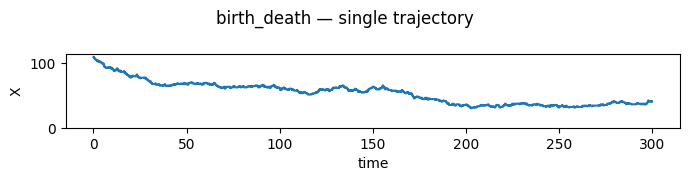

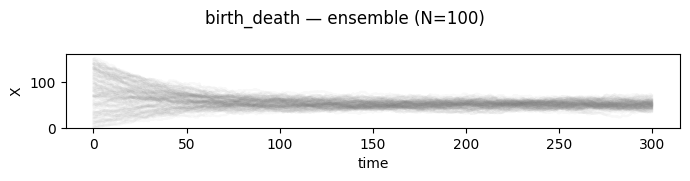

In [30]:
x0 = jax.random.randint(jax.random.PRNGKey(1), (N_REPLICATES, 1), minval=0, maxval=151)
run_and_plot(models.birth_death, x0=x0, n_steps=3000)

## Single gene

Constitutive transcription and translation: `∅ → R → R + P → ∅`. A two-stage cascade with mRNA `R` and protein `P`, each with first-order decay. Parameters are the Thattai & van Oudenaarden (2001) *E. coli* base case (mRNA half-life 2 min, protein half-life 30 min, translation burst size `k_P/γ_R = 20`).

**What to look for:**

- *Single trajectory*: starts at `[R=0, P=0]`. R hops up and down rapidly (low mean ~1.7, 2-min half-life), while P rises slowly toward `⟨P⟩ ≈ 520` over ~5 protein half-lives. Translational bursting is visible as P jumping by ~20 each time an mRNA appears.
- *Ensemble*: R has a tight Poisson-like band near 1–2. P shows the wider, more skewed distribution characteristic of bursty gene expression. Fano factor `≈ 1 + burst_size = 21`.

Params: {'k_R': 0.6, 'gamma_R': 0.3466, 'k_P': 6.931, 'gamma_P': 0.0231}


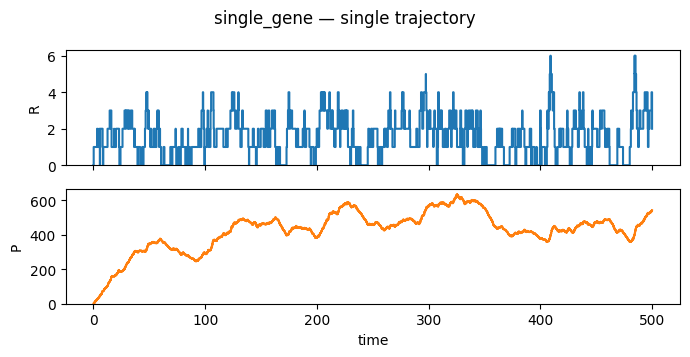

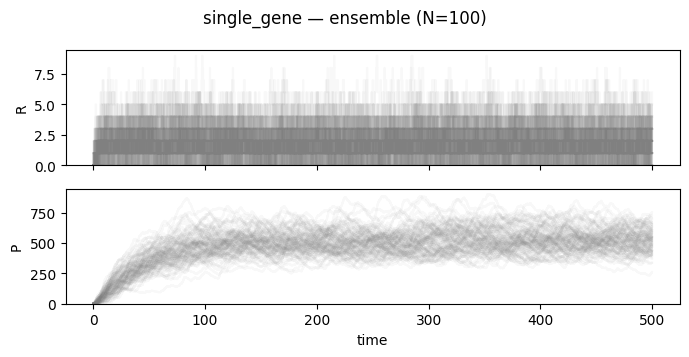

In [31]:
x0 = jnp.zeros((N_REPLICATES, 2), dtype=jnp.int32)
run_and_plot(models.single_gene, x0=x0, n_steps=5000)

## Negative autoregulation

A single TF `X` represses its own production via a Hill term: `∅ → X` at rate `β₁·Kⁿ/(Kⁿ + Xⁿ)`. The canonical noise-reducing motif (Becskei & Serrano 2000; Rosenfeld, Elowitz & Alon 2002), negative autoregulation speeds the response time and tightens the stationary distribution compared to unregulated expression.

**What to look for:**

- *Single trajectory*: starts somewhere in `[0, 100]`; self-repression pulls it back toward `⟨X⟩ ≈ 15` faster than simple decay would.
- *Ensemble*: wide initial spread collapses to a narrow band, the negative feedback actively buffers fluctuations.

Params: {'beta_0': 0.0, 'beta_1': 1.1552, 'K': 10.0, 'n': 2.0, 'delta': 0.0231}


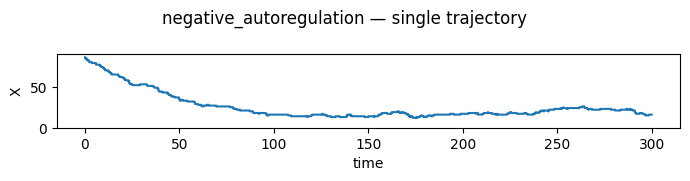

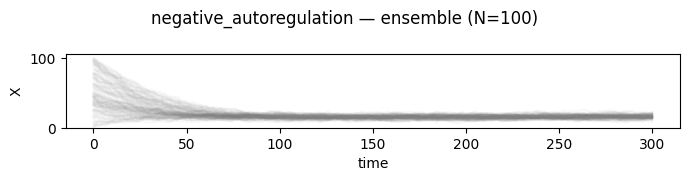

In [32]:
x0 = jax.random.randint(jax.random.PRNGKey(4), (N_REPLICATES, 1), minval=0, maxval=101)
run_and_plot(models.negative_autoregulation, x0=x0, n_steps=3000)

## Positive autoregulation (graded)

Same single-TF circuit but with self-activation through a Hill term. With sub-cooperative or modest cooperativity and a 5% basal leak (typical *E. coli* promoter), the equilibrium is monostable and graded. The system slowly rises to a single fixed point.

**What to look for:**

- *Single trajectory*: rises (or falls) toward `⟨X⟩ ≈ 51` over a noticeably **slower** time than simple decay: positive feedback delays the response.
- *Ensemble*: the spread tightens around 51 but more slowly than the negative-autoregulation case. The single fixed point is reached eventually.

Params: {'beta_0': 0.0578, 'beta_1': 1.1552, 'K': 10.0, 'n': 2.0, 'delta': 0.0231}


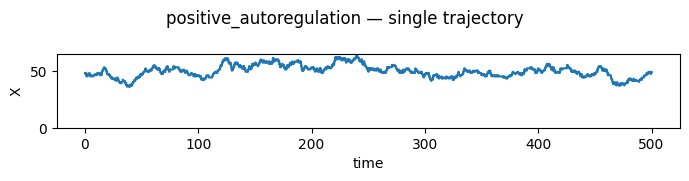

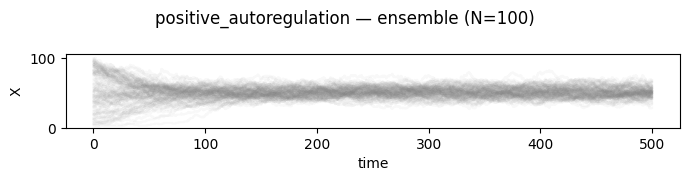

In [33]:
x0 = jax.random.randint(jax.random.PRNGKey(5), (N_REPLICATES, 1), minval=0, maxval=101)
run_and_plot(models.positive_autoregulation, x0=x0, n_steps=5000)

## Positive autoregulation — bistable regime

The same circuit as above with sharper cooperativity (`n=4`) flipped into a *bistable* regime via `Params.bistable()`. Three deterministic fixed points: `X_low ≈ 2.5` (stable), `X_saddle ≈ 15`, `X_high ≈ 51` (stable). The 5% basal leak ensures the low state isn't strictly absorbing at `X = 0`

**What to look for:**

- *Single trajectory*: depending on whether `x0[0]` is above or below the saddle (~15), the trajectory commits to one basin and stays there over the simulation horizon.
- *Ensemble*: cells with `x0 < 15` end up in the low basin (`X ≈ 2.5`), cells with `x0 > 15` end up high (`X ≈ 51`). At steady state the per-cell distribution is bimodal.

Params: {'beta_0': 0.0578, 'beta_1': 1.1552, 'K': 20.0, 'n': 4.0, 'delta': 0.0231}


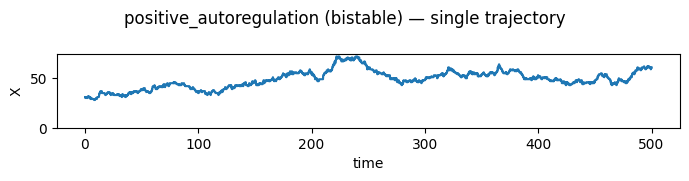

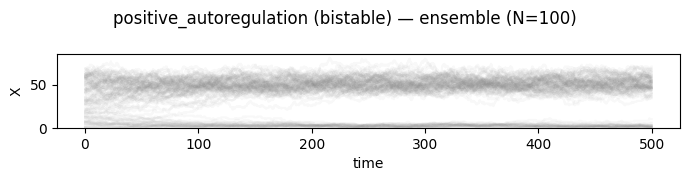

In [34]:
x0 = jax.random.randint(jax.random.PRNGKey(6), (N_REPLICATES, 1), minval=0, maxval=70)
run_and_plot(
    models.positive_autoregulation,
    x0=x0,
    n_steps=5000,
    params=models.positive_autoregulation.Params.bistable(),
    title="positive_autoregulation (bistable)",
)

## Linear cascade

A two-node activation cascade: `A` is produced constitutively, `A` activates `B` through a Hill term. The simplest open signalling cascade, useful as a baseline for studying propagation delay and noise filtering.

**What to look for:**

- *Single trajectory*: from `[0, 0]`, A rises first toward `⟨A⟩ = 50`; B follows with a noticeable delay, settling near `⟨B⟩ ≈ 26`.
- *Ensemble*: both species collapse onto their respective stationary bands, with B lagging A by ~one protein decay time.

Params: {'alpha_A': 1.1552, 'delta_A': 0.0231, 'beta_B0': 0.01155, 'beta_B1': 1.1552, 'K_A': 50.0, 'n_A': 2.0, 'delta_B': 0.0231}


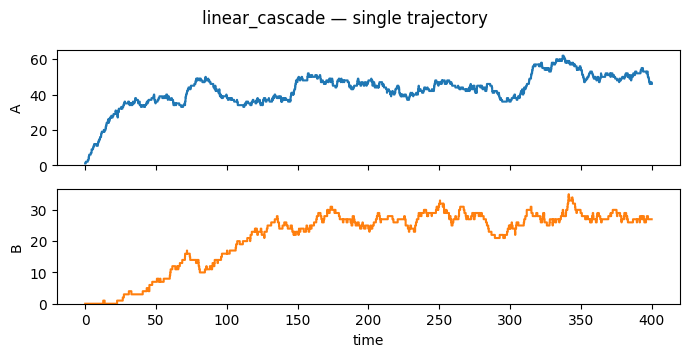

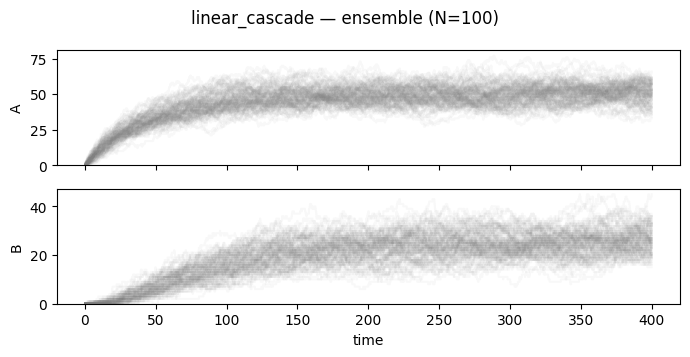

In [35]:
x0 = jnp.zeros((N_REPLICATES, 2), dtype=jnp.int32)
run_and_plot(models.linear_cascade, x0=x0, n_steps=4000)

## Toggle switch

Two TFs `A = LacI` and `B = TetR` that mutually repress each other (Gardner, Cantor & Collins 2000). Parameters are the Lugagne et al. (2017) *E. coli* fit, adiabatically reduced from their 8-reaction model. Three deterministic fixed points: **LacI-wins** `(A≈660, B≈ 63)`, **TetR-wins** `(A≈18, B≈864)`, saddle at `(A≈73, B≈228)`. Units are arbitrary fluorescence (a.u.), not molecule counts.

We seed `x0` half inside each basin (50 + 50 cells) so the ensemble plot shows clean bimodal commitment.

**What to look for:**

- *Single trajectory*: the first cell starts well inside the LacI basin (high A, low B); the trajectory commits to LacI-wins and dwells there.
- *Ensemble (N=100)*: two visibly separated bands per species — A splits between ~660 and ~18, B between ~63 and ~864. Strongly anti-correlated within each cell.

Params: {'beta_A0': 0.2246, 'beta_A1': 58.23, 'beta_B0': 1.005, 'beta_B1': 17.39, 'K_A': 31.94, 'K_B': 30.0, 'n_A': 2.0, 'n_B': 2.0, 'delta_A': 0.0165, 'delta_B': 0.0165}


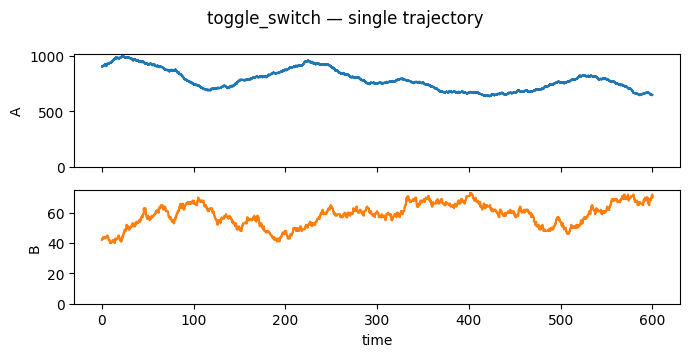

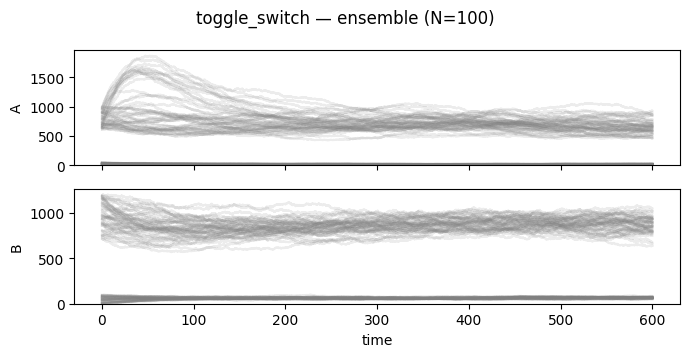

In [37]:
k_LacI, k_TetR = jax.random.split(jax.random.PRNGKey(8))
N_HALF = N_REPLICATES // 2
x0_LacI = jax.random.randint(k_LacI, (N_HALF, 2), minval=jnp.array([600, 0]), maxval=jnp.array([1000, 100]))
x0_TetR = jax.random.randint(k_TetR, (N_HALF, 2), minval=jnp.array([0, 700]), maxval=jnp.array([50, 1200]))
x0 = jnp.concatenate([x0_LacI, x0_TetR], axis=0)
run_and_plot(models.toggle_switch, x0=x0, n_steps=6000, alpha=0.15)

## Incoherent feed-forward loop (I1-FFL)

Three nodes: `A` activates both `B` and `C`, and `B` represses `C`. The two paths from A to C have opposing signs: a direct activation path and an indirect repression path, producing a transient pulse on C (Mangan & Alon 2003). When A turns on, C rises fast (B is still low, so no repression yet). Then B catches up and represses C, which falls back to a low steady state. This is a lassic adaptive-response motif.

We seed `A = 50` (already at SS), `B = C = 0`, which mimics "input signal just turned on".

**What to look for:**

- *Single trajectory*: A stays around 50 throughout. B rises slowly toward ~48. C transiently spikes up to ~5 in the first ~30 min, then falls back toward ~0.5 as B catches up.
- *Ensemble*: the C pulse is visible in the mean of the grey band — a transient bump up then back down. Both A and B settle into tight stationary bands.

Params: {'alpha_A': 1.1552, 'delta_A': 0.0231, 'beta_B0': 0.0, 'beta_B1': 1.1552, 'K_A': 10.0, 'n_A': 2.0, 'delta_B': 0.0231, 'beta_C0': 0.0, 'beta_C1': 1.1552, 'K_B': 5.0, 'n_B': 2.0, 'delta_C': 0.0231}


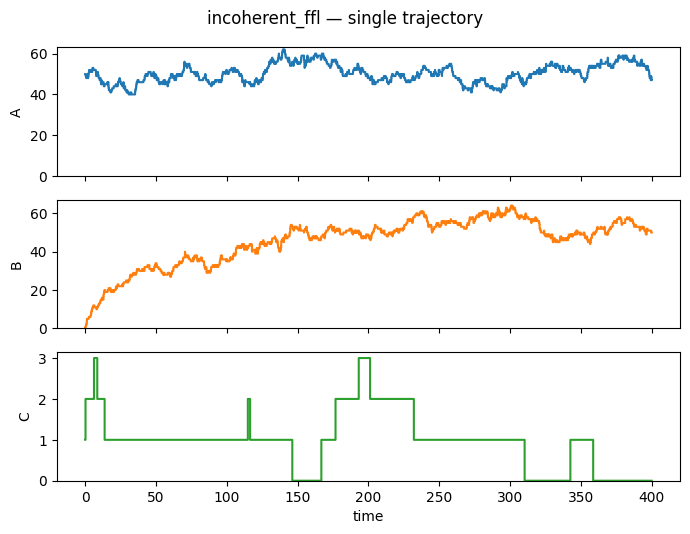

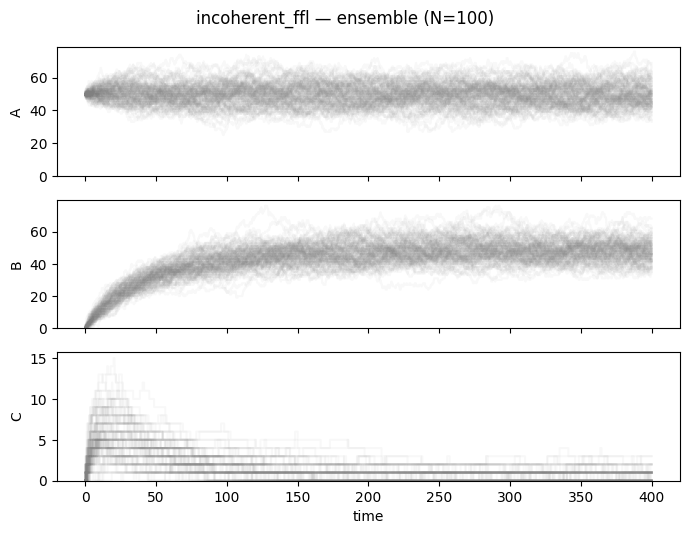

In [39]:
x0_A = jnp.full((N_REPLICATES, 1), 50, dtype=jnp.int32)
x0_BC = jnp.zeros((N_REPLICATES, 2), dtype=jnp.int32)
x0 = jnp.concatenate([x0_A, x0_BC], axis=-1)
run_and_plot(models.incoherent_ffl, x0=x0, n_steps=4000)

## Repressilator

Three TFs in a repressive ring: `A ⊣ B ⊣ C ⊣ A` (Elowitz & Leibler 2000 *E. coli* synthetic oscillator). Adiabatically reduced from Elowitz's 6-species (mRNA + protein) model, with Hill cooperativity bumped from `n=2` to `n=3` to preserve oscillation in the reduced form (see docstring). 10-min LVA-tagged protein half-life. Predicted period is ~150–165 min, matching Elowitz's experimental observation.

**What to look for:**

- *Single trajectory*: clean limit-cycle oscillation — A, B, C take turns being high, each peaking at `⟨X⟩_max ≈ 5000–9000` monomers and falling to near 0 while the next one rises. Period ~165 min, period-to-period variability ~few percent.
- *Ensemble*: with `N=100` cells starting at random phases, individual cycles average out — the grey band is broad and roughly flat, hiding the oscillation at the population level. The single-trajectory view is what reveals the cycle.

Params: {'beta_A0': 0.6, 'beta_A1': 600.0, 'beta_B0': 0.6, 'beta_B1': 600.0, 'beta_C0': 0.6, 'beta_C1': 600.0, 'K_A': 40.0, 'K_B': 40.0, 'K_C': 40.0, 'n': 3.0, 'delta_A': 0.0693, 'delta_B': 0.0693, 'delta_C': 0.0693}


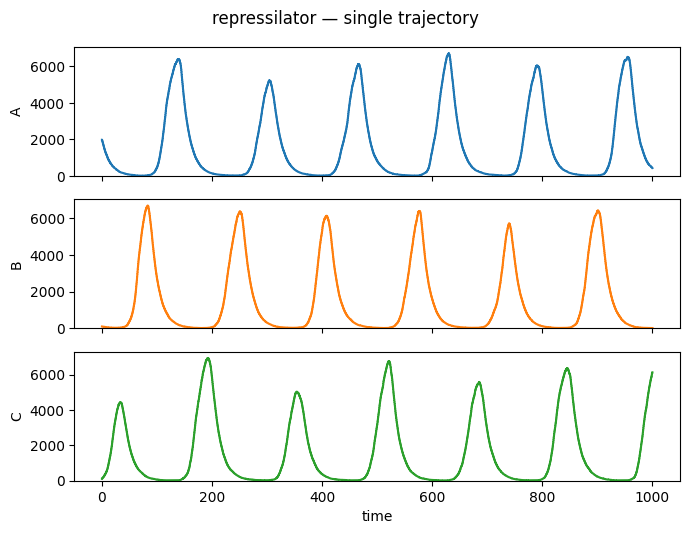

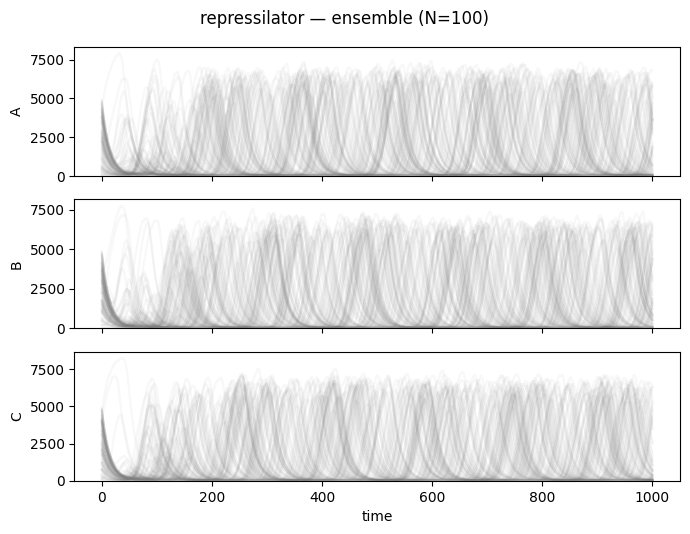

In [3]:
# Seed first replicate with asymmetric initial state so the single trajectory shows
# a clean cycle quickly. Tmaining replicates uniformly sample [0, 5000] across all
# species.
x0_random = jax.random.randint(jax.random.PRNGKey(13), (N_REPLICATES - 1, 3), minval=0, maxval=5001)
x0_first = jnp.array([[2000, 100, 100]], dtype=jnp.int32)
x0 = jnp.concatenate([x0_first, x0_random], axis=0)
run_and_plot(models.repressilator, x0=x0, n_steps=5000, dt=0.2)